# Objetivo 4 — Entrenamiento y Evaluacion Comparativa
Todos los modelos bajo el mismo protocolo experimental (PPI Fase 3).  
**Modelos:** ResNet-18 · HQC-CNN · PEQML · HQCINN-shallow · HQCINN-deep  
**Metricas:** accuracy, F1-macro, sensibilidad, especificidad, AUC, inf/img, params  
**Estadistica:** ANOVA + t-Student (α=0.05), IC 95% bootstrap

## 0 · Instalacion

In [7]:
import subprocess, sys
pkgs = [
    'torch torchvision --index-url https://download.pytorch.org/whl/cu118',
    'pennylane>=0.38',
    'pennylane-lightning[gpu]',
    'scikit-learn pandas matplotlib seaborn tqdm',
]
for pkg in pkgs:
    subprocess.run([sys.executable,'-m','pip','install','-q']+pkg.split(), check=False)
print('OK')


OK


## 1 · Imports y seed global

In [8]:
import os, random, time, json
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, WeightedRandomSampler
import pennylane as qml
from pennylane.qnn import TorchLayer
from tqdm.notebook import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, recall_score
)
from scipy import stats

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('PennyLane:', qml.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))


PyTorch: 2.12.0+cpu
PennyLane: 0.45.0
Device: cpu


## 2 · Rutas, DataLoaders y class weights

In [9]:
BASE_DIR  = Path(os.getcwd())
CHEST_OUT = BASE_DIR / 'etl_output' / 'chest_xray'
LUNG_OUT  = BASE_DIR / 'etl_output' / 'lung_cancer'
CKPT_DIR  = BASE_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

BATCH_SIZE    = 32
IMG_SIZE      = (128, 128)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_train = T.Compose([
    T.Resize(IMG_SIZE), T.Grayscale(num_output_channels=3),
    T.RandomRotation(10), T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15),
    T.RandomAffine(degrees=0, scale=(0.90, 1.10)),
    T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
transform_eval = T.Compose([
    T.Resize(IMG_SIZE), T.Grayscale(num_output_channels=3),
    T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def make_loaders(root, weighted=False):
    root = Path(root)
    ds_tr = ImageFolder(root/'train', transform=transform_train)
    ds_va = ImageFolder(root/'val',   transform=transform_eval)
    ds_te = ImageFolder(root/'test',  transform=transform_eval)
    if weighted:
        tgts = torch.tensor(ds_tr.targets)
        sw   = (1.0/torch.bincount(tgts).float())[tgts]
        ltr  = DataLoader(ds_tr, batch_size=BATCH_SIZE,
                          sampler=WeightedRandomSampler(sw,len(sw),True),
                          num_workers=2, pin_memory=True)
    else:
        ltr  = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
    lva = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    lte = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    return ltr, lva, lte, ds_tr.class_to_idx

chest_train_l, chest_val_l, chest_test_l, chest_cls = make_loaders(CHEST_OUT)
lung_train_l,  lung_val_l,  lung_test_l,  lung_cls  = make_loaders(LUNG_OUT, weighted=True)
N_CHEST = len(chest_cls)
N_LUNG  = len(lung_cls)

tgts    = torch.tensor(ImageFolder(LUNG_OUT/'train').targets)
lung_cw = (1.0/torch.bincount(tgts).float())
lung_cw = (lung_cw/lung_cw.sum()).to(DEVICE)

CHEST_NAMES = ['NORMAL', 'PNEUMONIA']
LUNG_NAMES  = ['Benign', 'Malignant', 'Normal']
print('Chest:', chest_cls, '| Lung:', lung_cls)
print('Lung class weights:', lung_cw)


Chest: {'NORMAL': 0, 'PNEUMONIA': 1} | Lung: {'Benign': 0, 'Malignant': 1, 'Normal': 2}
Lung class weights: tensor([0.6654, 0.1426, 0.1921])


## 3 · Definicion de modelos
Todas las arquitecturas definidas en esta celda para evitar dependencias externas.

In [10]:
# ── constante compartida por todos los modelos HQCNN ──────────────────────
N_QUBITS = 4

# ── backend PennyLane ─────────────────────────────────────────────────────
def get_qdevice(n_qubits):
    if torch.cuda.is_available():
        try:
            dev = qml.device('lightning.gpu', wires=n_qubits)
            return dev
        except Exception:
            pass
    return qml.device('default.qubit', wires=n_qubits)

# ── Modelo 0: ResNet-18 (Obj 3) ───────────────────────────────────────────
def build_resnet18(n_classes):
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, N_QUBITS), nn.ReLU(),
        nn.Linear(N_QUBITS, n_classes)
    )
    return m

# ── Modelo 1: HQC-CNN (Dong et al., 2023) ────────────────────────────────
dev_hqccnn = get_qdevice(N_QUBITS)

@qml.qnode(dev_hqccnn, interface='torch', diff_method='adjoint')
def circuit_hqccnn(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='X')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

class HQCCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4)),
        )
        self.pre_q = nn.Sequential(
            nn.Linear(64*4*4,64), nn.ReLU(), nn.Linear(64,N_QUBITS), nn.Tanh()
        )
        self.q_layer    = TorchLayer(circuit_hqccnn, {'weights':(2,N_QUBITS,3)})
        self.classifier = nn.Linear(N_QUBITS, n_classes)
    def forward(self, x):
        x = self.features(x).flatten(1)
        x = self.pre_q(x) * torch.pi
        return self.classifier(self.q_layer(x))

# ── Modelo 2: PEQML (Abdur & Kim, 2025) ──────────────────────────────────
dev_peqml = get_qdevice(N_QUBITS)

@qml.qnode(dev_peqml, interface='torch', diff_method='adjoint')
def circuit_peqml(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

class PEQML(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        def dw(ic,oc,s=1):
            return nn.Sequential(
                nn.Conv2d(ic,ic,3,stride=s,padding=1,groups=ic,bias=False),
                nn.Conv2d(ic,oc,1,bias=False), nn.BatchNorm2d(oc), nn.ReLU6())
        self.features = nn.Sequential(
            nn.Conv2d(3,8,3,stride=2,padding=1,bias=False), nn.BatchNorm2d(8), nn.ReLU6(),
            dw(8,16,2), dw(16,32,2), dw(32,32,2), nn.AdaptiveAvgPool2d((2,2)),
        )
        self.pre_q      = nn.Sequential(nn.Linear(32*2*2,N_QUBITS), nn.Tanh())
        self.q_layer    = TorchLayer(circuit_peqml, {'weights':(2,N_QUBITS)})
        self.classifier = nn.Linear(N_QUBITS, n_classes)
    def forward(self, x):
        x = self.features(x).flatten(1)
        x = self.pre_q(x) * torch.pi
        return self.classifier(self.q_layer(x))

# ── Modelo 3: HQCINN (Akpinar et al., 2025) ──────────────────────────────
def _build_hqcinn_qlayer(n_layers, entanglement='linear'):
    dev = get_qdevice(N_QUBITS)
    def entangle(wires, et):
        n = len(wires)
        if et=='linear':   [qml.CNOT(wires=[wires[i],wires[i+1]]) for i in range(n-1)]
        elif et=='circular':[qml.CNOT(wires=[wires[i],wires[(i+1)%n]]) for i in range(n)]
        elif et=='full':   [qml.CNOT(wires=[wires[i],wires[j]]) for i in range(n) for j in range(i+1,n)]
    @qml.qnode(dev, interface='torch', diff_method='adjoint')
    def circuit(inputs, weights_rx, weights_ry, weights_rz):
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='X')
        for l in range(n_layers):
            for q in range(N_QUBITS):
                qml.RX(weights_rx[l,q],wires=q)
                qml.RY(weights_ry[l,q],wires=q)
                qml.RZ(weights_rz[l,q],wires=q)
            entangle(list(range(N_QUBITS)), entanglement)
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    ws = {k:(n_layers,N_QUBITS) for k in ['weights_rx','weights_ry','weights_rz']}
    return TorchLayer(circuit, ws)

class HQCINN(nn.Module):
    VARIANTS = {'shallow':1, 'deep':3}
    def __init__(self, n_classes, variant='shallow', entanglement='linear'):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((2,2)),
        )
        self.pre_q      = nn.Sequential(nn.Linear(128*2*2,N_QUBITS), nn.Tanh())
        self.q_layer    = _build_hqcinn_qlayer(self.VARIANTS[variant], entanglement)
        self.classifier = nn.Linear(N_QUBITS, n_classes)
    def forward(self, x):
        x = self.features(x).flatten(1)
        x = self.pre_q(x) * torch.pi
        return self.classifier(self.q_layer(x))

# ── Factory ───────────────────────────────────────────────────────────────
def build_model(name, n_classes):
    if name == 'resnet18':          return build_resnet18(n_classes)
    elif name == 'hqccnn':          return HQCCNN(n_classes)
    elif name == 'peqml':           return PEQML(n_classes)
    elif name == 'hqcinn_shallow':  return HQCINN(n_classes, variant='shallow')
    elif name == 'hqcinn_deep':     return HQCINN(n_classes, variant='deep')
    else: raise ValueError(name)

MODEL_NAMES = ['resnet18','hqccnn','peqml','hqcinn_shallow','hqcinn_deep']

# Verificacion rapida de shapes
print('Verificacion de shapes:')
with torch.no_grad():
    x = torch.randn(2,3,128,128)
    for mn in MODEL_NAMES:
        m = build_model(mn, 2)
        p = sum(pp.numel() for pp in m.parameters() if pp.requires_grad)
        print(f'  {mn:<20} out={m(x).shape}  params={p:,}')


Verificacion de shapes:
  resnet18             out=torch.Size([2, 2])  params=11,178,574
  hqccnn               out=torch.Size([2, 2])  params=89,702
  peqml                out=torch.Size([2, 2])  params=3,094
  hqcinn_shallow       out=torch.Size([2, 2])  params=95,770
  hqcinn_deep          out=torch.Size([2, 2])  params=95,794


## 4 · Funciones de entrenamiento y evaluacion

In [11]:
def train_one_model(model, train_loader, val_loader, class_weights=None,
                    max_epochs=50, patience=5, save_path=None):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10], gamma=0.1)
    hist = {'train_loss':[],'val_loss':[],'val_acc':[],'val_f1':[]}
    best_f1, no_imp = 0.0, 0
    for ep in range(1, max_epochs+1):
        model.train(); tloss = 0.0
        for imgs, lbls in tqdm(train_loader, desc=f'Ep {ep}/{max_epochs}', leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward(); optimizer.step()
            tloss += loss.item()*imgs.size(0)
        scheduler.step()
        avg_tr = tloss/len(train_loader.dataset)
        model.eval(); vloss, preds, labs = 0.0, [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                logits = model(imgs)
                vloss += criterion(logits, lbls).item()*imgs.size(0)
                preds.extend(logits.argmax(1).cpu().numpy())
                labs.extend(lbls.cpu().numpy())
        avg_va  = vloss/len(val_loader.dataset)
        val_acc = sum(p==l for p,l in zip(preds,labs))/len(labs)
        val_f1  = f1_score(labs, preds, average='macro', zero_division=0)
        hist['train_loss'].append(avg_tr); hist['val_loss'].append(avg_va)
        hist['val_acc'].append(val_acc);   hist['val_f1'].append(val_f1)
        print(f'Ep {ep:3d} | train={avg_tr:.4f} | val={avg_va:.4f} | acc={val_acc:.4f} | F1={val_f1:.4f}')
        if val_f1 > best_f1:
            best_f1, no_imp = val_f1, 0
            if save_path: torch.save(model.state_dict(), save_path)
        else:
            no_imp += 1
            if no_imp >= patience: print(f'Early stopping ep {ep}'); break
    return hist


def compute_metrics(model, test_loader, class_names, model_name):
    model = model.to(DEVICE).eval()
    preds, labs, probs = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for imgs, lbls in test_loader:
            logits = model(imgs.to(DEVICE))
            probs.extend(torch.softmax(logits,1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(lbls.numpy())
    inf_ms = (time.time()-t0)/len(labs)*1000
    n_cls  = len(class_names)
    acc    = accuracy_score(labs, preds)
    f1_mac = f1_score(labs, preds, average='macro', zero_division=0)
    sens   = recall_score(labs, preds, average='macro', zero_division=0)
    cm     = confusion_matrix(labs, preds)
    spec_list = []
    for i in range(n_cls):
        TP=cm[i,i]; FN=cm[i,:].sum()-TP; FP=cm[:,i].sum()-TP; TN=cm.sum()-TP-FN-FP
        spec_list.append(TN/(TN+FP) if (TN+FP)>0 else 0.0)
    spec = float(np.mean(spec_list))
    try:
        auc = roc_auc_score(labs,probs,multi_class='ovr',average='macro') \
              if n_cls>2 else roc_auc_score(labs,[p[1] for p in probs])
    except Exception: auc = float('nan')
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n=== {model_name} ===')
    print(f'  Acc={acc:.4f}  F1={f1_mac:.4f}  Sens={sens:.4f}  Spec={spec:.4f}  AUC={auc:.4f}')
    print(f'  Inf={inf_ms:.3f}ms  Params={params:,}')
    print(classification_report(labs,preds,target_names=class_names,zero_division=0))
    # Confusion matrix
    plt.figure(figsize=(max(4,n_cls*2),max(3,n_cls*1.5)))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}'); plt.ylabel('Real'); plt.xlabel('Predicho')
    plt.tight_layout(); plt.show()
    return dict(model=model_name,acc=acc,f1=f1_mac,sens=sens,spec=spec,
                auc=auc,inf_ms=inf_ms,params=params,preds=preds,labs=labs,probs=probs)


def plot_history(hist, title):
    fig,axes = plt.subplots(1,2,figsize=(12,4))
    fig.suptitle(f'Curvas — {title}', fontweight='bold')
    axes[0].plot(hist['train_loss'],label='train'); axes[0].plot(hist['val_loss'],label='val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(hist['val_acc'],label='acc'); axes[1].plot(hist['val_f1'],label='F1-macro')
    axes[1].set_title('Val Accuracy / F1'); axes[1].legend()
    plt.tight_layout(); plt.show()


print('Funciones listas.')


Funciones listas.


## 5 · Seleccion de dataset
Cambia `DATASET` antes de ejecutar los bloques de entrenamiento.

In [12]:
DATASET = 'chest'   # 'chest' | 'lung'

if DATASET == 'chest':
    train_l, val_l, test_l = chest_train_l, chest_val_l, chest_test_l
    n_cls, cls_names, cw   = N_CHEST, CHEST_NAMES, None
else:
    train_l, val_l, test_l = lung_train_l, lung_val_l, lung_test_l
    n_cls, cls_names, cw   = N_LUNG, LUNG_NAMES, lung_cw

save_dir = CKPT_DIR / DATASET
save_dir.mkdir(exist_ok=True)

results   = {}   # resultados de test por modelo
histories = {}   # curvas de entrenamiento por modelo

print(f'Dataset: {DATASET} | clases={cls_names} | n_train={len(train_l.dataset)}')


Dataset: chest | clases=['NORMAL', 'PNEUMONIA'] | n_train=4099


## 6 · Entrenamiento — ResNet-18

Ep 1/50:   0%|          | 0/129 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep   1 | train=0.2093 | val=0.1075 | acc=0.9579 | F1=0.9480


Ep 2/50:   0%|          | 0/129 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep   5 | train=0.1172 | val=0.1279 | acc=0.9453 | F1=0.9263


Ep 6/50:   0%|          | 0/129 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep   6 | train=0.1114 | val=0.1253 | acc=0.9476 | F1=0.9326
Early stopping ep 6


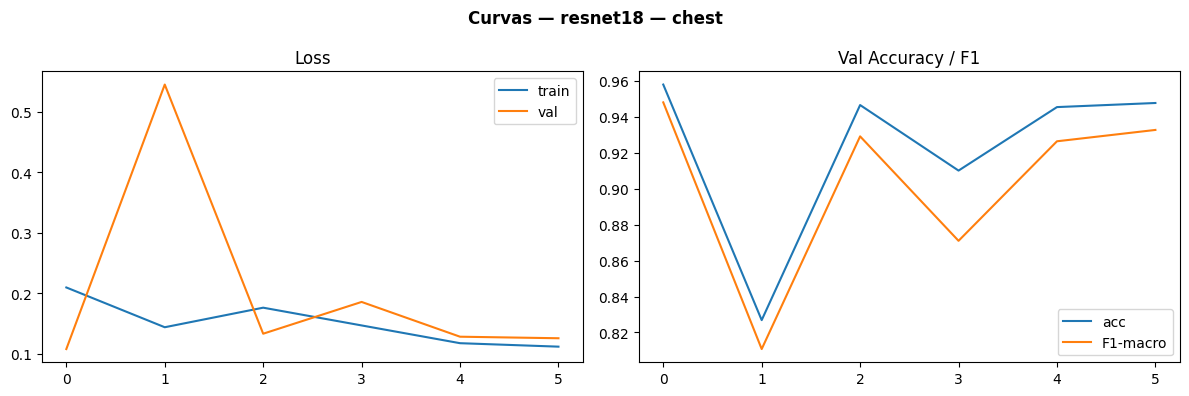

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== resnet18 ===
  Acc=0.9522  F1=0.9409  Sens=0.9514  Spec=0.9514  AUC=0.9909
  Inf=23.535ms  Params=11,178,574
              precision    recall  f1-score   support

      NORMAL       0.88      0.95      0.91       238
   PNEUMONIA       0.98      0.95      0.97       641

    accuracy                           0.95       879
   macro avg       0.93      0.95      0.94       879
weighted avg       0.95      0.95      0.95       879



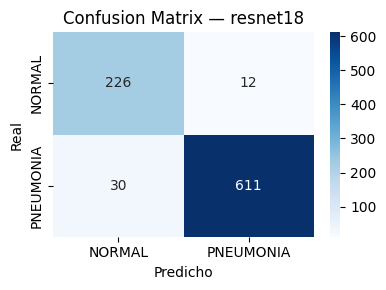

In [13]:
_mname = 'resnet18'
_ckpt  = str(save_dir / f'{_mname}_best.pt')
_model = build_model(_mname, n_cls).to(DEVICE)

histories[_mname] = train_one_model(
    _model, train_l, val_l, class_weights=cw,
    max_epochs=50, patience=5, save_path=_ckpt
)
plot_history(histories[_mname], f'{_mname} — {DATASET}')
_model.load_state_dict(torch.load(_ckpt, map_location=DEVICE))
results[_mname] = compute_metrics(_model, test_l, cls_names, _mname)


## 7 · Entrenamiento — HQC-CNN

Ep 1/50:   0%|          | 0/129 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep   1 | train=0.4887 | val=0.3806 | acc=0.9169 | F1=0.8844


Ep 2/50:   0%|          | 0/129 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep  14 | train=0.1216 | val=0.1241 | acc=0.9601 | F1=0.9501


Ep 15/50:   0%|          | 0/129 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep  15 | train=0.1198 | val=0.1363 | acc=0.9533 | F1=0.9423
Early stopping ep 15


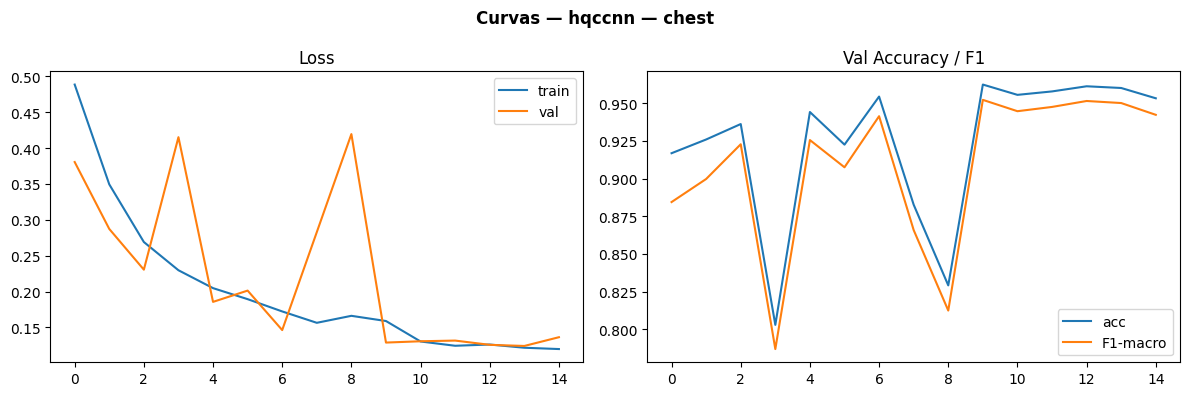

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== hqccnn ===
  Acc=0.9488  F1=0.9346  Sens=0.9306  Spec=0.9306  AUC=0.9707
  Inf=74.136ms  Params=89,702
              precision    recall  f1-score   support

      NORMAL       0.92      0.89      0.90       238
   PNEUMONIA       0.96      0.97      0.97       641

    accuracy                           0.95       879
   macro avg       0.94      0.93      0.93       879
weighted avg       0.95      0.95      0.95       879



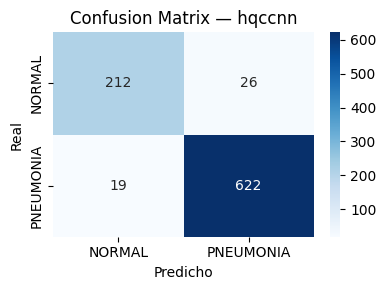

In [14]:
_mname = 'hqccnn'
_ckpt  = str(save_dir / f'{_mname}_best.pt')
_model = build_model(_mname, n_cls).to(DEVICE)

histories[_mname] = train_one_model(
    _model, train_l, val_l, class_weights=cw,
    max_epochs=50, patience=5, save_path=_ckpt
)
plot_history(histories[_mname], f'{_mname} — {DATASET}')
_model.load_state_dict(torch.load(_ckpt, map_location=DEVICE))
results[_mname] = compute_metrics(_model, test_l, cls_names, _mname)


## 8 · Entrenamiento — PEQML

In [ ]:
_mname = 'peqml'
_ckpt  = str(save_dir / f'{_mname}_best.pt')
_model = build_model(_mname, n_cls).to(DEVICE)

histories[_mname] = train_one_model(
    _model, train_l, val_l, class_weights=cw,
    max_epochs=50, patience=5, save_path=_ckpt
)
plot_history(histories[_mname], f'{_mname} — {DATASET}')
_model.load_state_dict(torch.load(_ckpt, map_location=DEVICE))
results[_mname] = compute_metrics(_model, test_l, cls_names, _mname)


## 9 · Entrenamiento — HQCINN-shallow

In [ ]:
_mname = 'hqcinn_shallow'
_ckpt  = str(save_dir / f'{_mname}_best.pt')
_model = build_model(_mname, n_cls).to(DEVICE)

histories[_mname] = train_one_model(
    _model, train_l, val_l, class_weights=cw,
    max_epochs=50, patience=5, save_path=_ckpt
)
plot_history(histories[_mname], f'{_mname} — {DATASET}')
_model.load_state_dict(torch.load(_ckpt, map_location=DEVICE))
results[_mname] = compute_metrics(_model, test_l, cls_names, _mname)


## 10 · Entrenamiento — HQCINN-deep

In [ ]:
_mname = 'hqcinn_deep'
_ckpt  = str(save_dir / f'{_mname}_best.pt')
_model = build_model(_mname, n_cls).to(DEVICE)

histories[_mname] = train_one_model(
    _model, train_l, val_l, class_weights=cw,
    max_epochs=50, patience=5, save_path=_ckpt
)
plot_history(histories[_mname], f'{_mname} — {DATASET}')
_model.load_state_dict(torch.load(_ckpt, map_location=DEVICE))
results[_mname] = compute_metrics(_model, test_l, cls_names, _mname)


## 11 · Tabla comparativa de metricas

In [ ]:
rows = []
for mn, r in results.items():
    rows.append({'Modelo':mn, 'Accuracy':round(r['acc'],4), 'F1-macro':round(r['f1'],4),
                 'Sensibilidad':round(r['sens'],4), 'Especificidad':round(r['spec'],4),
                 'AUC':round(r['auc'],4), 'Inf(ms)':round(r['inf_ms'],3), 'Params':r['params']})

df = pd.DataFrame(rows).set_index('Modelo')
print(f'=== Dataset: {DATASET} ===')
print(df.to_string())
df.to_csv(BASE_DIR / f'resultados_{DATASET}.csv')
print(f'Guardado: resultados_{DATASET}.csv')


## 12 · Visualizacion comparativa

In [ ]:
metrics_plot = ['Accuracy','F1-macro','Sensibilidad','Especificidad','AUC']
fig, axes = plt.subplots(1, len(metrics_plot), figsize=(18,4))
fig.suptitle(f'Comparativa — {DATASET}', fontweight='bold')
palette = sns.color_palette('Set2', len(df))
for ax, met in zip(axes, metrics_plot):
    vals = df[met].values
    bars = ax.bar(df.index, vals, color=palette)
    ax.set_title(met); ax.set_ylim(0,1.05)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=7)
plt.tight_layout(); plt.show()


## 13 · Analisis estadistico — ANOVA + t-Student (α = 0.05)
IC 95% bootstrap sobre predicciones de test.

In [ ]:
def f1_bootstrap(preds, labs, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    sz  = len(labs)
    return [f1_score(np.array(labs)[rng.integers(0,sz,sz)],
                     np.array(preds)[rng.integers(0,sz,sz)],
                     average='macro', zero_division=0) for _ in range(n)]

print(f'IC 95% F1-macro — {DATASET}')
dists = {}
for mn, r in results.items():
    dists[mn] = f1_bootstrap(r['preds'], r['labs'])
    ci = np.percentile(dists[mn], [2.5,97.5])
    print(f'  {mn:<20} F1={r["f1"]:.4f}  IC95=[{ci[0]:.4f}, {ci[1]:.4f}]')

# ANOVA
f_stat, p_anova = stats.f_oneway(*dists.values())
print(f'\nANOVA — F={f_stat:.4f}  p={p_anova:.6f}')
print('Significativo (α=0.05):', p_anova < 0.05)

# t-Student pareado
print('\nt-Student pareado:')
pair_rows = []
for m1, m2 in combinations(list(dists.keys()), 2):
    t, p = stats.ttest_ind(dists[m1], dists[m2])
    sig  = '*' if p < 0.05 else ''
    pair_rows.append({'Par':f'{m1} vs {m2}','t':round(t,4),'p':round(p,6),'sig':sig})
    print(f'  {m1} vs {m2}: t={t:.4f}  p={p:.6f}  {sig}')

pd.DataFrame(pair_rows).to_csv(BASE_DIR / f'ttest_{DATASET}.csv', index=False)
print(f'Guardado: ttest_{DATASET}.csv')


## 14 · Guardar resultados consolidados

In [ ]:
summary = {
    'dataset': DATASET,
    'metrics': {mn:{k:v for k,v in r.items() if k not in ('preds','labs','probs')}
                for mn,r in results.items()},
    'anova': {'F':round(float(f_stat),4), 'p':round(float(p_anova),6)},
    'ttest_pairs': pair_rows,
}
out = BASE_DIR / f'resultados_completos_{DATASET}.json'
with open(out,'w') as f: json.dump(summary, f, indent=2, default=str)
print(f'Guardado: {out}')
